# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [13]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())



Missing Values:
sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64

Summary Statistics:
           sensor_id            lat            lon       pressure  \
count  701548.000000  701548.000000  701548.000000  701548.000000   
mean     2835.419842      42.679722      23.333739   94965.292500   
std       798.018890       0.025568       0.039365    2577.210945   
min      1764.000000      42.622000      23.240000       0.000000   
25%      2224.000000      42.665000      23.310000   94528.017500   
50%      2323.000000      42.685000      23.332000   95005.480000   
75%      3474.000000      42.694000      23.360000   95405.132500   
max      4661.000000      42.738000      23.419000  164926.750000   

         temperature       humidity  
count  701548.000000  701548.000000  
mean       24.754990      48.348949  
std        14.013001      20.907247  
min      -145.120000       0.000000  
25%        20.630000      34.140000 

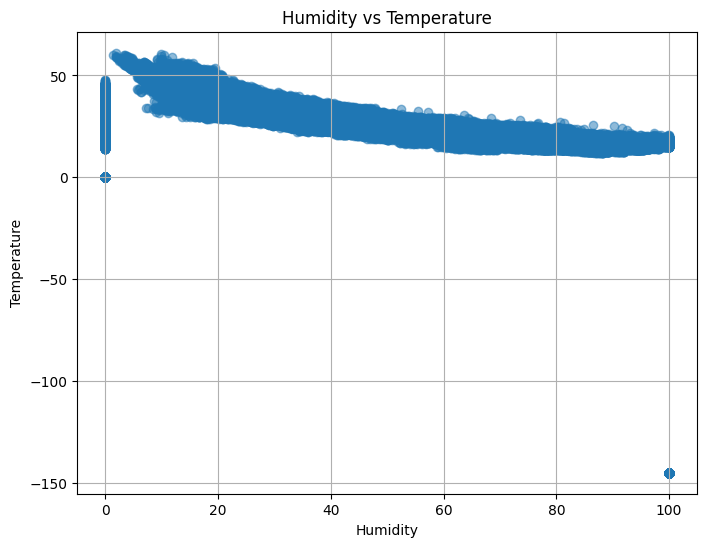

In [4]:
# Scatter plot to observe relationship
plt.figure(figsize=(8,6))
plt.scatter(df['humidity'], df['temperature'], alpha=0.5)

plt.title('Humidity vs Temperature')
plt.xlabel('Humidity')
plt.ylabel('Temperature')
plt.grid(True)

plt.show()

## Data Preprocessing

In [5]:
# Drop any rows with missing values
df = df.dropna()

# Define features and target
X = df[['humidity']]
y = df['temperature']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Model Training

first 10 Predicted Temperature Values:
[14.93681105 32.06608596 18.21935337 23.49462409 28.31265918 20.42022634
 27.8247137  25.69549706 41.25174493 41.25174493]


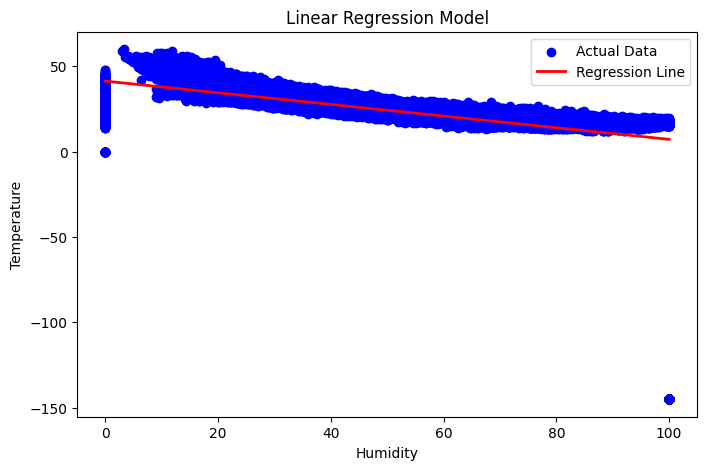


Intercept (b0): 41.2517449302205
Coefficient (b1): -0.34122061568718376

Regression Equation:
Temperature = 41.2517 + (-0.3412 × Humidity)


In [14]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict
linear_pred = linear_model.predict(X_test)

print("first 10 Predicted Temperature Values:")
print(linear_pred[:10])

plt.figure(figsize=(8,5))

# Sort values for a smooth regression line
sorted_idx = np.argsort(X_test['humidity'].values)

# Actual data
plt.scatter(
    X_test['humidity'],
    y_test,
    color='blue',
    label='Actual Data'
)

# Regression line
plt.plot(
    X_test['humidity'].values[sorted_idx],
    linear_pred[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Linear Regression Model")
plt.legend()

plt.show()

# Display equation
print("\nIntercept (b0):", linear_model.intercept_)
print("Coefficient (b1):", linear_model.coef_[0])

print("\nRegression Equation:")
print(
    f"Temperature = {linear_model.intercept_:.4f} "
    f"+ ({linear_model.coef_[0]:.4f} × Humidity)"
)

## Evaluation


In [8]:
# Evaluate model performance
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 3.8748170683297953
MSE: 144.08481646510754
R² Score: 0.25704416703650235


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


Now using another model like Polynomial regression to predict the temperature based on humidity data.

First 10 Predicted Temperature Values:
[11.39122821 32.31089852 18.37942639 26.65082031 31.01772837 22.2738158
 30.71396222 29.02317432 27.68507386 27.68507386]


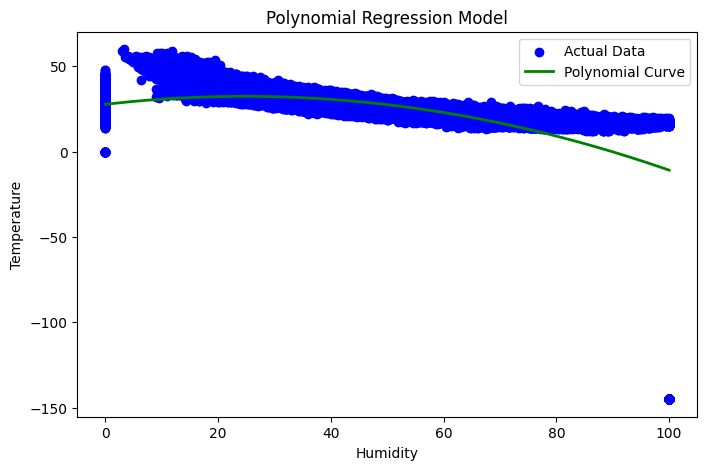

Intercept: 27.685073863353903
Coefficients: [ 0.          0.37728336 -0.00763177]


Polynomial Regression Results
MAE: 4.620205822885475
MSE: 124.23083423545124
R² Score: 0.3594188118253159


In [16]:
# Polynomial Features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Polynomial Regression Model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)

print("First 10 Predicted Temperature Values:")
print(poly_pred[:10])

sorted_idx = np.argsort(X_test['humidity'].values)

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X_test['humidity'],
    y_test,
    color='blue',
    label='Actual Data'
)

plt.plot(
    X_test['humidity'].values[sorted_idx],
    poly_pred[sorted_idx],
    color='green',
    linewidth=2,
    label='Polynomial Curve'
)

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Polynomial Regression Model")
plt.legend()

plt.show()

# Coefficients
print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

# Evaluation
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_r2 = r2_score(y_test, poly_pred)

print("\n")
print("Polynomial Regression Results")
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("R² Score:", poly_r2)

In [10]:
print("\nModel Comparison")
print("Linear Regression")
print("R²:", linear_r2)

print("\nPolynomial Regression")
print("R²:", poly_r2)

if poly_r2 > linear_r2:
    print("\nPolynomial Regression performs better.")
else:
    print("\nLinear Regression performs better.")


Model Comparison
Linear Regression
R²: 0.25704416703650235

Polynomial Regression
R²: 0.3594188118253159

Polynomial Regression performs better.
